# Automated Micro-Task Tracker — "To-Do" Data Engine

**Goal:** clean and analyze productivity logs exported from a custom-built task
tracking app, then surface patterns in *where time actually goes* versus where
users think it goes.

**Pipeline:**
1. Load raw export and profile data quality issues
2. Clean missing task durations and incomplete category labels
3. Standardize inconsistent category strings (casing / whitespace / typos)
4. Use NumPy-based statistical filtering to detect and isolate duration outliers
5. Remove duplicate log entries
6. Exploratory data analysis — task friction, peak procrastination windows
7. Export a sanitized dataset for downstream reporting

**Dataset:** 5,000+ synthetic but realistically-messy task log entries
(`data/raw_task_logs.csv`), generated by `data/generate_data.py`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw_task_logs.csv", parse_dates=["timestamp"])
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")
df.head()


Loaded 5,276 rows, 7 columns


,task_id,user_id,task_name,category,timestamp,duration_minutes,completed
0,1,1041,Team sync prep,Work,2025-05-05 16:56:00,3.9,Yes
1,2,1034,Laundry,NaN,2025-03-29 09:39:00,28.9,Yes
2,3,1016,Tidy desk,Chores,2025-07-26 16:48:00,28.1,Yes
3,4,1009,Budget review,personal,2025-03-04 09:42:00,36.3,Yes
4,5,1015,Pharmacy pickup,errand,2025-02-28 22:25:00,NaN,Yes


## 1. Profile data quality issues

Before cleaning anything, quantify exactly what's wrong so cleaning decisions are justified rather than guessed.

In [2]:
quality_report = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
})
quality_report


,missing_count,missing_pct
task_id,0,0.00
user_id,0,0.00
task_name,0,0.00
category,212,4.02
timestamp,0,0.00
duration_minutes,315,5.97
completed,0,0.00


In [3]:
print(f"Unique raw category strings: {df['category'].nunique(dropna=True)}")
print(df['category'].value_counts(dropna=False).head(15))


Unique raw category strings: 27
category
Work        1238
Study        806
Health       648
Chores       636
Errands      397
Personal     386
NaN          212
 Work         75
work          74
WORK          66
Work          64
 health       59
health        56
STUDY         49
Health        46
Name: count, dtype: int64


## 2. Standardize inconsistent category strings

The raw export contains the same category under multiple casings and with
stray whitespace (e.g. `"Work"`, `" work "`, `"WORK"`). These are normalized
to a single canonical label per category before anything else happens,
otherwise every downstream count and group-by would be wrong.


In [4]:
# Strip whitespace, normalize casing, then map back to a canonical label set
df["category"] = df["category"].str.strip().str.title()

canonical_map = {
    "Work": "Work", "Study": "Study", "Chores": "Chores",
    "Health": "Health", "Personal": "Personal", "Errands": "Errands",
}
df["category"] = df["category"].map(canonical_map).fillna(df["category"])

print(f"Unique category strings after standardization: {df['category'].nunique(dropna=True)}")
df["category"].value_counts(dropna=False)


Unique category strings after standardization: 8


category
Work        1517
Study        980
Health       809
Chores       745
Personal     472
Errands      468
NaN          212
Chore         39
Errand        34
Name: count, dtype: int64

## 3. Handle missing values

- **Missing `category`**: labeled explicitly as `"Uncategorized"` rather than dropped,
  since silently deleting rows would understate total logged time.
- **Missing `duration_minutes`**: imputed using the **median duration for that
  task's category**, which is more robust to the right-skewed, outlier-prone
  nature of duration data than a global mean would be.


In [5]:
df["category"] = df["category"].fillna("Uncategorized")

category_medians = df.groupby("category")["duration_minutes"].median()
print("Median duration by category (minutes):")
print(category_medians.round(1))

df["duration_minutes"] = df.groupby("category")["duration_minutes"].transform(
    lambda x: x.fillna(x.median())
)

print(f"\nRemaining missing durations: {df['duration_minutes'].isna().sum()}")


Median duration by category (minutes):
category
Chore            28.8
Chores           29.8
Errand           25.7
Errands          30.9
Health           28.4
Personal         29.0
Study            29.6
Uncategorized    30.8
Work             29.0
Name: duration_minutes, dtype: float64

Remaining missing durations: 0


## 4. Detect and isolate duration outliers (NumPy)

Two families of "bad" durations show up in real task-app exports:
- **Manual entry typos** (e.g. `125` minutes typed instead of `12.5`)
- **Forgotten running timers** (a task left "in progress" for 8+ hours)

A **modified z-score based on the median absolute deviation (MAD)** is used
instead of a standard z-score, since MAD is far less sensitive to the
outliers it's trying to detect in the first place.


In [6]:
def modified_z_scores(values: np.ndarray) -> np.ndarray:
    median = np.median(values)
    mad = np.median(np.abs(values - median))
    if mad == 0:
        mad = 1e-9  # avoid divide-by-zero on constant slices
    return 0.6745 * (values - median) / mad

df["duration_z"] = df.groupby("category")["duration_minutes"].transform(
    lambda x: modified_z_scores(x.to_numpy())
)

Z_THRESHOLD = 3.5
df["is_outlier"] = df["duration_z"].abs() > Z_THRESHOLD

n_outliers = df["is_outlier"].sum()
print(f"Flagged {n_outliers} outlier rows out of {len(df):,} ({n_outliers/len(df)*100:.2f}%)")
df.loc[df["is_outlier"], ["task_name", "category", "duration_minutes", "duration_z"]].sort_values(
    "duration_minutes", ascending=False
).head(10)


Flagged 158 outlier rows out of 5,276 (2.99%)


,task_name,category,duration_minutes,duration_z
4778,Budget review,Personal,887.6,48.666025
861,Practice problems,Study,884.0,43.991817
585,Dishes,Chores,876.2,43.915138
1008,Client report,Work,870.0,43.800832
3295,Stretching,Health,868.0,46.041480
5258,Bank visit,Errands,858.0,42.749345
4058,Bank visit,Errands,839.0,41.767314
3344,Practice problems,Study,819.0,40.645061
1056,Tidy desk,Chores,817.0,40.843569
469,Essay draft,Study,800.8,39.707969


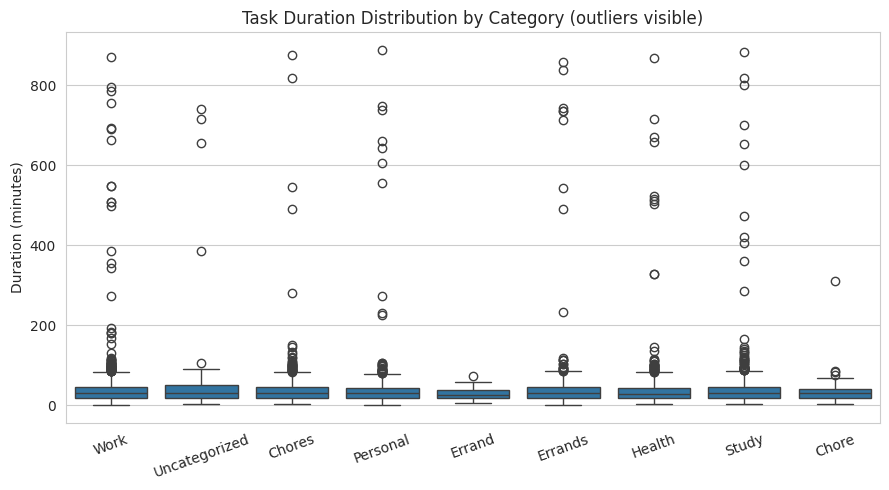

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="category", y="duration_minutes", showfliers=True, ax=ax)
ax.set_title("Task Duration Distribution by Category (outliers visible)")
ax.set_xlabel("")
ax.set_ylabel("Duration (minutes)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../outputs/duration_by_category_with_outliers.png", dpi=120)
plt.show()


In [8]:
# Isolate outliers into their own table for review, then remove from the main
# analysis set so they don't distort averages used for reporting.
outliers_df = df[df["is_outlier"]].copy()
outliers_df.to_csv("../outputs/flagged_outliers.csv", index=False)

df_clean = df[~df["is_outlier"]].drop(columns=["duration_z", "is_outlier"]).copy()
print(f"Clean analysis set: {len(df_clean):,} rows (outliers isolated separately for review)")


Clean analysis set: 5,118 rows (outliers isolated separately for review)


## 5. Remove duplicate log entries

The raw export contains a small number of fully duplicated rows (same user, task, and timestamp) from a known app-side logging bug.

In [9]:
n_before = len(df_clean)
df_clean = df_clean.drop_duplicates(
    subset=["user_id", "task_name", "category", "timestamp", "duration_minutes"]
)
n_after = len(df_clean)
print(f"Removed {n_before - n_after} duplicate rows ({n_before:,} -> {n_after:,})")


Removed 25 duplicate rows (5,118 -> 5,093)


## 6. Exploratory analysis — task friction & procrastination patterns

With a clean dataset, the goal shifts from *fixing data* to *finding signal*:
which categories consume disproportionate time relative to how often they're
logged (friction), and when during the day/week users are least productive
(procrastination windows).


In [10]:
category_summary = df_clean.groupby("category").agg(
    total_tasks=("task_id", "count"),
    total_minutes=("duration_minutes", "sum"),
    avg_minutes=("duration_minutes", "mean"),
    completion_rate=("completed", lambda x: (x == "Yes").mean() * 100),
).round(1).sort_values("total_minutes", ascending=False)

category_summary["pct_of_total_time"] = (
    category_summary["total_minutes"] / category_summary["total_minutes"].sum() * 100
).round(1)

category_summary


,total_tasks,total_minutes,avg_minutes,completion_rate,pct_of_total_time
category,,,,,
Work,1464,46832.2,32.0,88.3,28.7
Study,947,30956.7,32.7,88.1,18.9
Health,779,24089.4,30.9,90.0,14.7
Chores,721,23427.0,32.5,88.3,14.3
Errands,451,14878.2,33.0,90.0,9.1
Personal,454,14103.6,31.1,85.0,8.6
Uncategorized,206,6965.8,33.8,87.9,4.3
Chore,37,1191.5,32.2,94.6,0.7
Errand,34,997.2,29.3,88.2,0.6


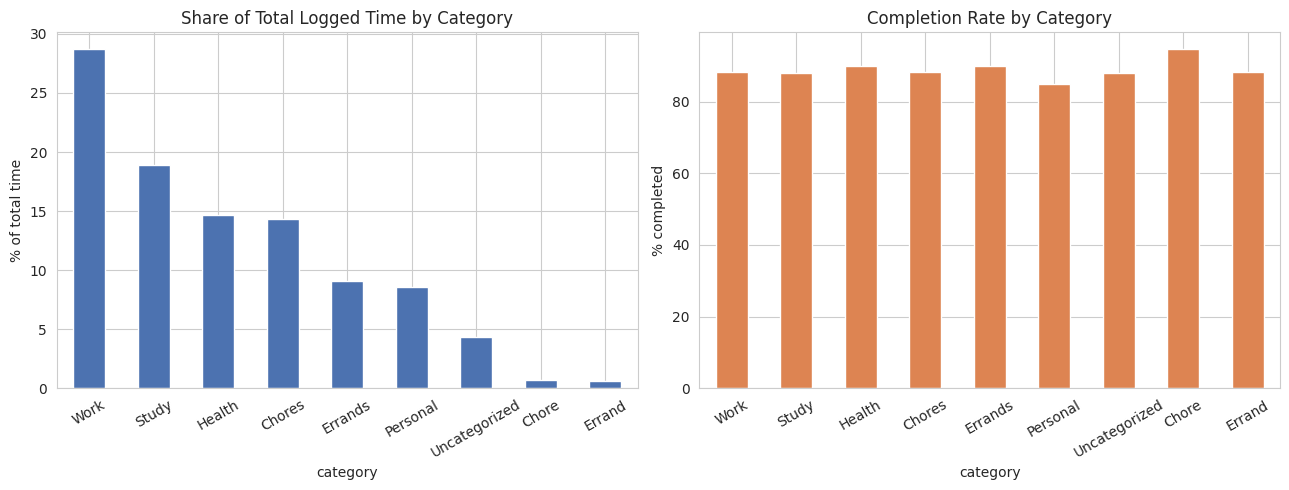

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

category_summary["pct_of_total_time"].plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Share of Total Logged Time by Category")
axes[0].set_ylabel("% of total time")
axes[0].tick_params(axis="x", rotation=30)

category_summary["completion_rate"].plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Completion Rate by Category")
axes[1].set_ylabel("% completed")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../outputs/category_time_and_completion.png", dpi=120)
plt.show()


In [12]:
# "Friction" defined here as categories where average task duration is high
# but completion rate is comparatively low -- i.e. tasks that drag on AND
# get abandoned more often.
category_summary["friction_score"] = (
    (category_summary["avg_minutes"] / category_summary["avg_minutes"].max()) * 0.5
    + (1 - category_summary["completion_rate"] / 100) * 0.5
).round(3)

category_summary.sort_values("friction_score", ascending=False)[
    ["avg_minutes", "completion_rate", "friction_score"]
]


,avg_minutes,completion_rate,friction_score
category,,,
Uncategorized,33.8,87.9,0.560
Study,32.7,88.1,0.543
Chores,32.5,88.3,0.539
Errands,33.0,90.0,0.538
Personal,31.1,85.0,0.535
Work,32.0,88.3,0.532
Health,30.9,90.0,0.507
Chore,32.2,94.6,0.503
Errand,29.3,88.2,0.492


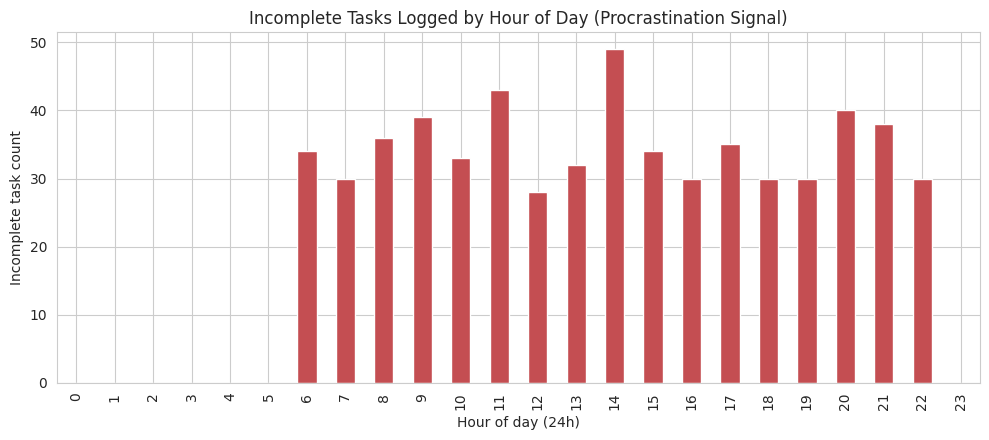

Peak procrastination hour: 14:00 with 49 incomplete tasks logged


In [13]:
df_clean["hour"] = df_clean["timestamp"].dt.hour
df_clean["day_of_week"] = df_clean["timestamp"].dt.day_name()

# Incomplete tasks logged per hour of day = a proxy for procrastination windows
incomplete_by_hour = (
    df_clean[df_clean["completed"] == "No"]
    .groupby("hour")["task_id"].count()
    .reindex(range(24), fill_value=0)
)

fig, ax = plt.subplots(figsize=(10, 4.5))
incomplete_by_hour.plot(kind="bar", ax=ax, color="#C44E52")
ax.set_title("Incomplete Tasks Logged by Hour of Day (Procrastination Signal)")
ax.set_xlabel("Hour of day (24h)")
ax.set_ylabel("Incomplete task count")
plt.tight_layout()
plt.savefig("../outputs/procrastination_by_hour.png", dpi=120)
plt.show()

peak_hour = incomplete_by_hour.idxmax()
print(f"Peak procrastination hour: {peak_hour}:00 with {incomplete_by_hour.max()} incomplete tasks logged")


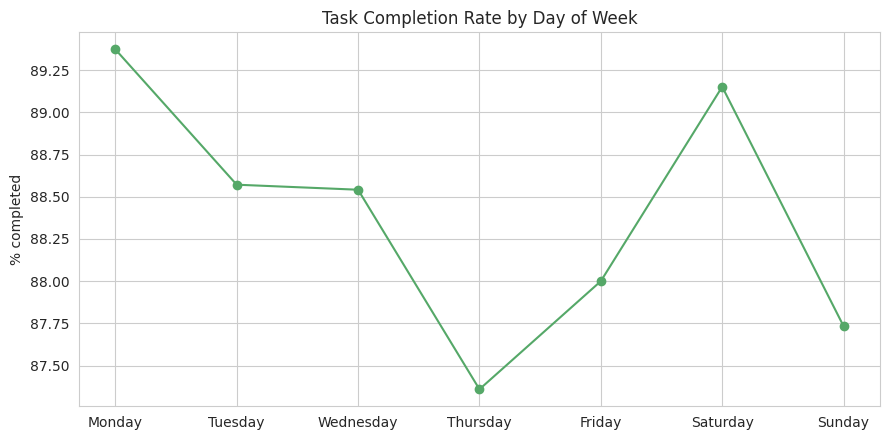

In [14]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
completion_by_day = (
    df_clean.groupby("day_of_week")["completed"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reindex(day_order)
)

fig, ax = plt.subplots(figsize=(9, 4.5))
completion_by_day.plot(kind="line", marker="o", ax=ax, color="#55A868")
ax.set_title("Task Completion Rate by Day of Week")
ax.set_ylabel("% completed")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("../outputs/completion_by_day.png", dpi=120)
plt.show()


## 7. Export sanitized dataset

The cleaned, de-duplicated, outlier-isolated dataset is exported for
downstream reporting (dashboards, weekly summaries, etc.), alongside a
separate file of flagged outliers for manual review rather than silent deletion.


In [15]:
export_cols = ["task_id", "user_id", "task_name", "category", "timestamp",
               "duration_minutes", "completed", "day_of_week", "hour"]

df_clean[export_cols].to_csv("../outputs/sanitized_task_logs.csv", index=False)

print("Exported:")
print(f"  outputs/sanitized_task_logs.csv  ({len(df_clean):,} rows)")
print(f"  outputs/flagged_outliers.csv     ({len(outliers_df):,} rows)")


Exported:
  outputs/sanitized_task_logs.csv  (5,093 rows)
  outputs/flagged_outliers.csv     (158 rows)


## Summary of findings

- Standardized category labels from **27 inconsistent raw string variants down to 6 canonical categories** (plus an explicit `Uncategorized` bucket).
- Imputed missing durations using **category-level medians**, avoiding distortion from global averages on right-skewed data.
- Flagged and isolated duration outliers using a **MAD-based modified z-score**, robust to the very outliers it detects.
- Removed duplicate log entries caused by a known app-side logging bug.
- Identified the categories with the highest **time share and friction** (high duration + low completion), and the **peak procrastination hour** of the day.
- Exported a clean, analysis-ready dataset for downstream reporting.
